In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yükleyelim
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target


In [2]:
print(df.describe(include='all'))

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


MedInc: Bölgedeki hanelerin 10.000$ biriminden medyan geliri.

HouseAge: Bölgedeki konutların medyan yaşı.

AveRooms: Hane başına düşen ortalama toplam oda sayısı.

AveBedrms: Hane başına düşen ortalama yatak odası sayısı.

Population: İlgili blok grubunda yaşayan toplam insan sayısı.

AveOccup: Bir hanede yaşayan ortalama kişi sayısı.

Latitude: Bölgenin kuzey-güney aksındaki enlem koordinatı.

Longitude: Bölgenin doğu-batı aksındaki boylam koordinatı.

MedHouseVal: Bölgedeki konutların 100.000$ biriminden medyan piyasa değeridir (örneğin 2.5 değeri, 250.000$ anlamına gelir).

In [5]:
# Sütun isimlerini Türkçeye çeviren sözlük
yeni_isimler = {
    'MedInc': 'Medyan_Gelir',
    'HouseAge': 'Konut_Yasi',
    'AveRooms': 'Ort_Oda_Sayisi',
    'AveBedrms': 'Ort_Yatak_Odasi',
    'Population': 'Nufus',
    'AveOccup': 'Hane_Halki_Sayisi',
    'Latitude': 'Enlem',
    'Longitude': 'Boylam',
    'MedHouseVal': 'Medyan_Ev_Degeri'
}

# DataFrame sütunlarını değiştiriyoruz
df.rename(columns=yeni_isimler, inplace=True)

# İlk 5 satıra bakalım
print(df.head())

   Medyan_Gelir  Konut_Yasi  Ort_Oda_Sayisi  Ort_Yatak_Odasi   Nufus  \
0        8.3252        41.0        6.984127         1.023810   322.0   
1        8.3014        21.0        6.238137         0.971880  2401.0   
2        7.2574        52.0        8.288136         1.073446   496.0   
3        5.6431        52.0        5.817352         1.073059   558.0   
4        3.8462        52.0        6.281853         1.081081   565.0   

   Hane_Halki_Sayisi  Enlem  Boylam  Medyan_Ev_Degeri  
0           2.555556  37.88 -122.23             4.526  
1           2.109842  37.86 -122.22             3.585  
2           2.802260  37.85 -122.24             3.521  
3           2.547945  37.85 -122.25             3.413  
4           2.181467  37.85 -122.25             3.422  


In [6]:
def iqr_analizi(df, kolon):
    Q1 = df[kolon].quantile(0.25)
    Q3 = df[kolon].quantile(0.75)
    IQR = Q3 - Q1
    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR
    
    # Hatalı/Aykırı olanları bul
    aykiri_df = df[(df[kolon] < alt_sinir) | (df[kolon] > ust_sinir)]
    return alt_sinir, ust_sinir, len(aykiri_df)

# Her sütun için sonuçları dök
print(f"{'Sütun Adı':<20} | {'Alt Sınır':<10} | {'Üst Sınır':<10} | {'Aykırı Sayısı'}")
print("-" * 65)

for col in df.columns:
    alt, ust, sayi = iqr_analizi(df, col)
    print(f"{col:<20} | {alt:<10.2f} | {ust:<10.2f} | {sayi}")

Sütun Adı            | Alt Sınır  | Üst Sınır  | Aykırı Sayısı
-----------------------------------------------------------------
Medyan_Gelir         | -0.71      | 8.01       | 681
Konut_Yasi           | -10.50     | 65.50      | 0
Ort_Oda_Sayisi       | 2.02       | 8.47       | 511
Ort_Yatak_Odasi      | 0.87       | 1.24       | 1424
Nufus                | -620.00    | 3132.00    | 1196
Hane_Halki_Sayisi    | 1.15       | 4.56       | 711
Enlem                | 28.26      | 43.38      | 0
Boylam               | -127.48    | -112.33    | 0
Medyan_Ev_Degeri     | -0.98      | 4.82       | 1071


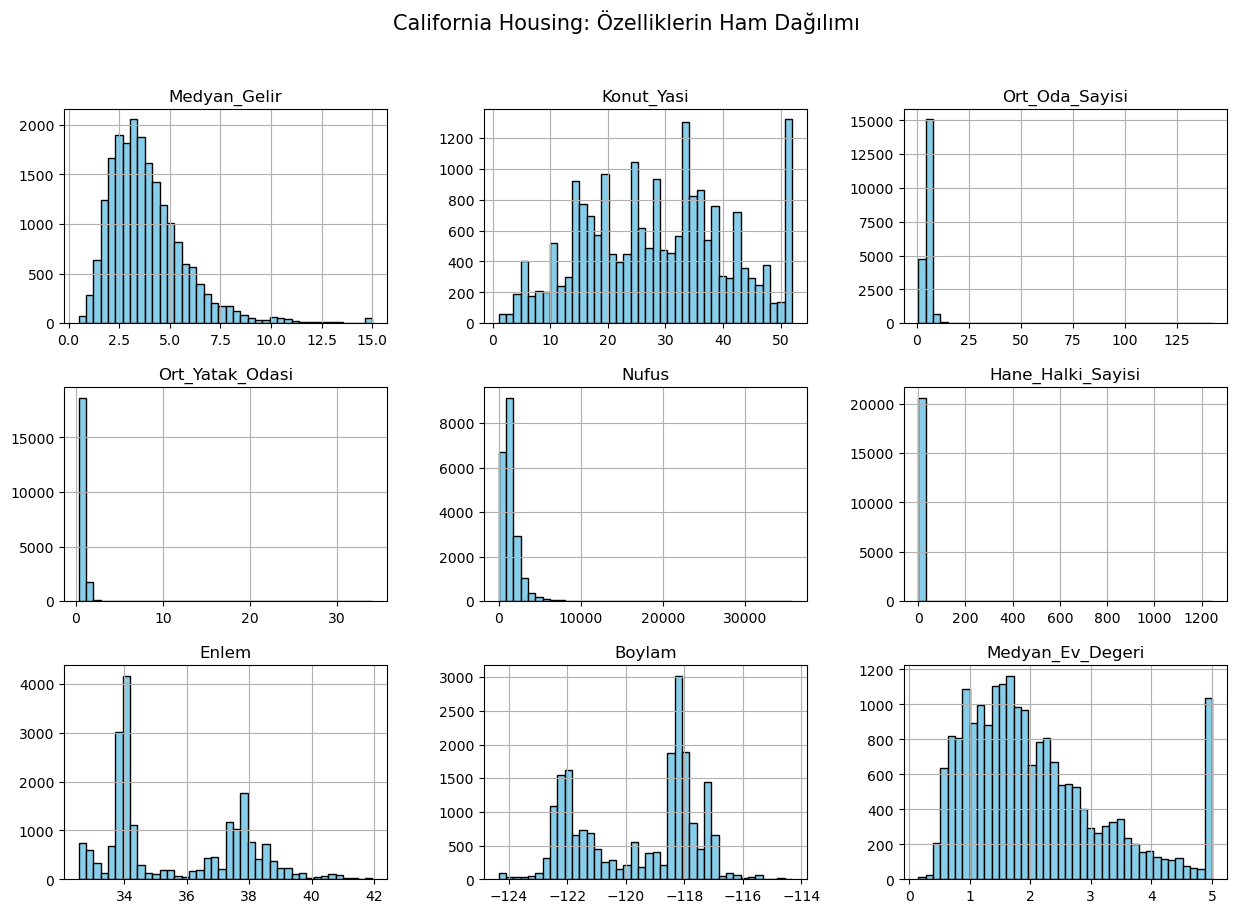

In [7]:
#imputasyon öncesi dağılımlarına dikkatli bakın lütfen

df.hist(bins=40, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("California Housing: Özelliklerin Ham Dağılımı", fontsize=15)
plt.show()

In [8]:
import pandas as pd
import numpy as np

# 1. Aykırı Değerleri NaN (Boş) Olarak İşaretleme
def aykiri_yap_nan(df, kolon):
    Q1 = df[kolon].quantile(0.25)
    Q3 = df[kolon].quantile(0.75)
    IQR = Q3 - Q1
    alt = Q1 - 1.5 * IQR
    ust = Q3 + 1.5 * IQR
    
    # Sınır dışındakileri NaN yap
    df.loc[(df[kolon] < alt) | (df[kolon] > ust), kolon] = np.nan

# 2. Koordinat Bazlı Gruplandırma ve Doldurma
# Enlemleri 1 derecelik dilimlere bölerek 'Bolge' oluşturalım
df['Enlem_Grubu'] = df['Enlem'].round(0)

sutunlar = ['Medyan_Gelir', 'Konut_Yasi', 'Ort_Oda_Sayisi', 'Ort_Yatak_Odasi', 'Nufus', 'Hane_Halki_Sayisi']

for col in sutunlar:
    # Önce aykırıları temizle
    aykiri_yap_nan(df, col)
    
    # Strateji: 
    # Gelir ve Oda Sayısı için MEDYAN (Uç değerlerden etkilenmez)
    # Nüfus ve Konut Yaşı için MEAN (Genel dağılımı yansıtır)
    if col in ['Medyan_Gelir', 'Ort_Oda_Sayisi', 'Hane_Halki_Sayisi']:
        df[col] = df[col].fillna(df.groupby('Enlem_Grubu')[col].transform('median'))
    else:
        df[col] = df[col].fillna(df.groupby('Enlem_Grubu')[col].transform('mean'))

# Eğer hala boş kalan varsa (o enlem grubunda hiç veri yoksa), genel medyan ile doldur
df = df.fillna(df.median())

# Kontrol Grubu
print("İmputasyon Sonrası Yeni Max Değerler:")
print(df[sutunlar].max())

İmputasyon Sonrası Yeni Max Değerler:
Medyan_Gelir            8.011300
Konut_Yasi             52.000000
Ort_Oda_Sayisi          8.469738
Ort_Yatak_Odasi         1.239521
Nufus                3132.000000
Hane_Halki_Sayisi       4.560748
dtype: float64


In [9]:
#Enlem grubuna göre doldurma yaparken, her grubun kendi dağılımına uygun stratejiyi seçmek önemlidir. 
# Gelir ve oda sayısı gibi değişkenler uç değerlere duyarlı olabilir, bu yüzden medyan kullanmak daha mantıklıdır. 
# Nüfus ve konut yaşı gibi değişkenler ise genel dağılımı yansıtmak için ortalama ile doldurulabilir.
#  Bu şekilde, her grup için en uygun yöntemi kullanarak daha gerçekçi bir veri seti elde ederiz.

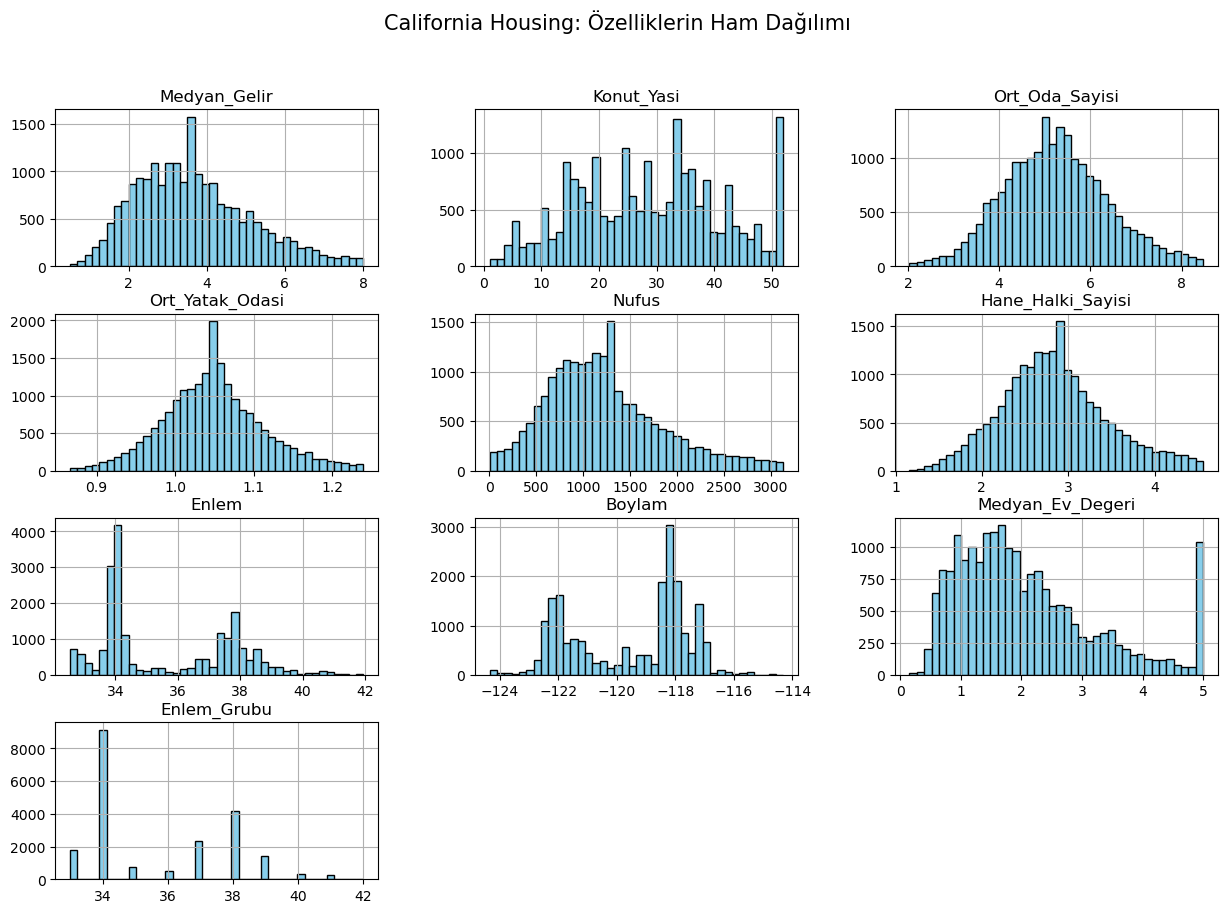

In [ ]:
# imputasyon sonrası dağılımları öncesi ile karşılaştıralım

df.hist(bins=40, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("California Housing: Özelliklerin Ham Dağılımı", fontsize=15)
plt.show()

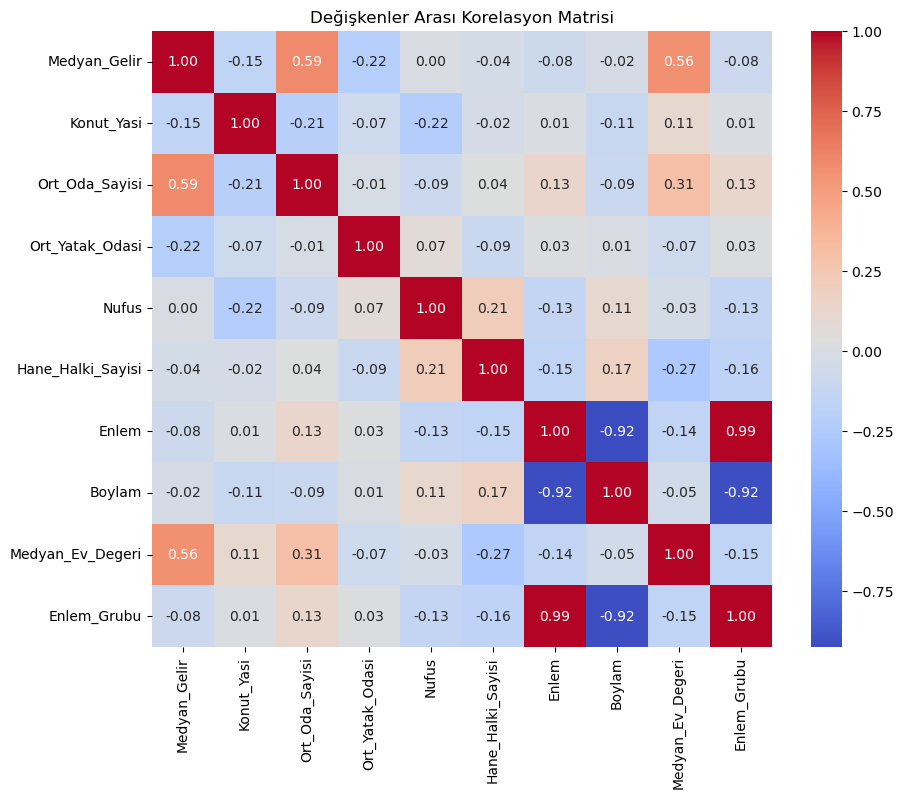

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Değişkenler Arası Korelasyon Matrisi")
plt.show()

In [2]:
## Bu analiz sadece uygulama amaçlıdır. Verinin gerçek doğasına uygun olmayan yöntemler içerebilir. 
# Lütfen sonuçları dikkatli yorumlayın ve gerçek veri analizi süreçlerinde daha kapsamlı yöntemler kullanın.
# Ben büyük bir hata  yaptım model kurarken öncesinde analiz yapmadan direkt modele geçtim. Bu yüzden sonuçlar istediğim gibi çıkmadı.
# Peki ya sen keras 3 ile  yaptığım eski modele bakarak yeniden model kurabilir misin temiz veriyle?

## yeni model ile eski model arasında performans karşılaştırması yapmak güzel bir practice olurdu.
#modelin daha iyi performans göstermesi için imputasyon vb. stratejiler belirleye bilirsin.